# Imports

In [1]:
import sys
import os
import json
import joblib
from pathlib import Path

In [2]:
sys.path.append(os.path.join(os.getcwd(),"..",".."))

In [3]:
import numpy as np
import pandas as pd

In [4]:
from evaluating_signals import Evaluating_Signals

In [5]:
trade_price_store=Path(os.getcwd()).parent.parent/"Data_Store"

In [6]:
data_store=Path(os.getcwd()).parent.parent/"Prepared_Data_Store"

# Loading Models

In [7]:
ridge18=joblib.load(os.path.join(data_store,"ridge_18.pkl"))
ridge17=joblib.load(os.path.join(data_store,"ridge_17.pkl"))
ridge16=joblib.load(os.path.join(data_store,"ridge_16.pkl"))
ridge15=joblib.load(os.path.join(data_store,"ridge_15.pkl"))
ridge14=joblib.load(os.path.join(data_store,"ridge_14.pkl"))

# Loading Traded Tickers

In [8]:
with open(os.path.join(data_store,"stocks_to_traded.json"),"r") as file:
    tickers=json.load(file)

# Loading Trade Price Data

In [9]:
start_date=2010
end_date=2017

In [10]:
data=pd.read_csv(
    os.path.join(trade_price_store,"wiki_prices.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
).sort_index()

In [11]:
idx=pd.IndexSlice
data=data.loc[idx[str(start_date):str(end_date),tickers],"adj_open"]

In [12]:
data=data.swaplevel()

In [13]:
trade_prices=(data
              .shift(-1)
              .unstack("ticker")
              .sort_index()
              .tz_localize("UTC")
              .ffill()
             )

# Loading Feature Data

In [14]:
feature_data=pd.read_csv(
    os.path.join(data_store,"model1_train_X.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
)

# Signal Evaluation

In [15]:
signal_evaluator=Evaluating_Signals(
    quantiles=5,
    periods=[1,5,7,15,21],
    trade_prices=trade_prices
)

## Ridge Model-18 (alpha=50000)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.029152,0.002831,-0.002598,0.002632,113400,20.053582
2,-0.019146,0.003660,-0.000615,0.001901,113397,20.053052
3,-0.016400,0.004179,0.000227,0.001740,111891,19.786732
4,-0.014106,0.004716,0.000961,0.001582,113397,20.053052
5,-0.011418,0.011024,0.002029,0.001447,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.011,-0.002,-0.001,-0.000,-0.000
beta,0.005,0.008,0.013,0.019,0.015
Mean Period Wise Return Top Quantile (bps),-0.762,-0.115,-0.091,-0.028,-0.018
Mean Period Wise Return Bottom Quantile (bps),0.431,0.053,0.030,0.000,-0.004
Mean Period Wise Spread (bps),-1.193,-0.168,-0.120,-0.028,-0.013


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.003,-0.004,-0.004,-0.003,-0.002
IC Std.,0.051,0.050,0.050,0.050,0.052
Risk-Adjusted IC,-0.054,-0.085,-0.088,-0.053,-0.048
t-stat(IC),-2.089,-3.293,-3.425,-2.058,-1.849
p-value(IC),0.037,0.001,0.001,0.040,0.065
IC Skew,-0.190,-0.029,0.035,0.004,-0.010
IC Kurtosis,0.003,-0.090,0.024,-0.092,-0.107


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.357,0.572,0.665,0.736,0.723
Quantile 2 Mean Turnover,0.638,0.746,0.770,0.781,0.778
Quantile 3 Mean Turnover,0.682,0.765,0.783,0.792,0.791
Quantile 4 Mean Turnover,0.639,0.743,0.768,0.782,0.780
Quantile 5 Mean Turnover,0.379,0.597,0.685,0.732,0.710


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.755,0.423,0.253,0.133,0.173


<Figure size 640x480 with 0 Axes>

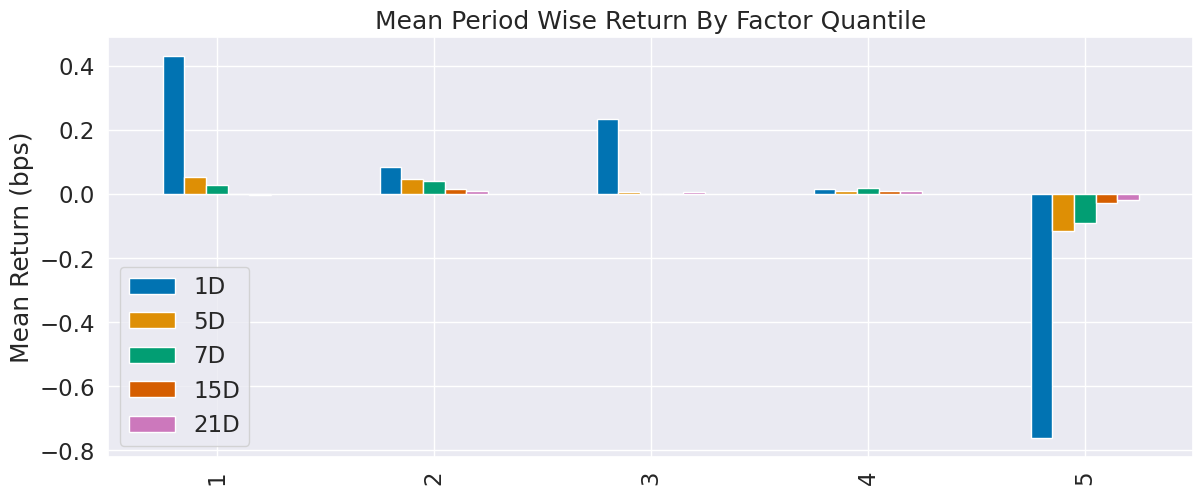

In [16]:
signal_evaluator.evaluate_signal(model=ridge18,feature_data=feature_data)

## Ridge Model-17 (alpha=10000)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.050972,0.006308,-0.004029,0.003946,113400,20.053582
2,-0.033325,0.007672,-0.001023,0.002796,113397,20.053052
3,-0.028885,0.008761,0.000286,0.002557,111891,19.786732
4,-0.024932,0.009868,0.001458,0.002349,113397,20.053052
5,-0.020093,0.022209,0.003312,0.002305,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.009,-0.002,-0.001,-0.000,-0.000
beta,0.006,0.010,0.014,0.018,0.015
Mean Period Wise Return Top Quantile (bps),-1.007,-0.070,-0.043,-0.009,-0.003
Mean Period Wise Return Bottom Quantile (bps),-0.266,0.025,0.006,-0.002,-0.004
Mean Period Wise Spread (bps),-0.741,-0.096,-0.049,-0.007,0.000


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.003,-0.004,-0.004,-0.002,-0.001
IC Std.,0.052,0.050,0.050,0.050,0.051
Risk-Adjusted IC,-0.058,-0.079,-0.072,-0.036,-0.026
t-stat(IC),-2.260,-3.058,-2.783,-1.393,-1.004
p-value(IC),0.024,0.002,0.005,0.164,0.316
IC Skew,-0.125,-0.016,0.059,0.066,0.039
IC Kurtosis,0.055,0.028,0.041,-0.059,-0.115


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.609,0.691,0.756,0.781,0.756
Quantile 2 Mean Turnover,0.755,0.774,0.790,0.791,0.788
Quantile 3 Mean Turnover,0.775,0.786,0.790,0.795,0.794
Quantile 4 Mean Turnover,0.755,0.775,0.786,0.792,0.787
Quantile 5 Mean Turnover,0.620,0.711,0.777,0.782,0.746


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.359,0.191,0.05,0.021,0.094


<Figure size 640x480 with 0 Axes>

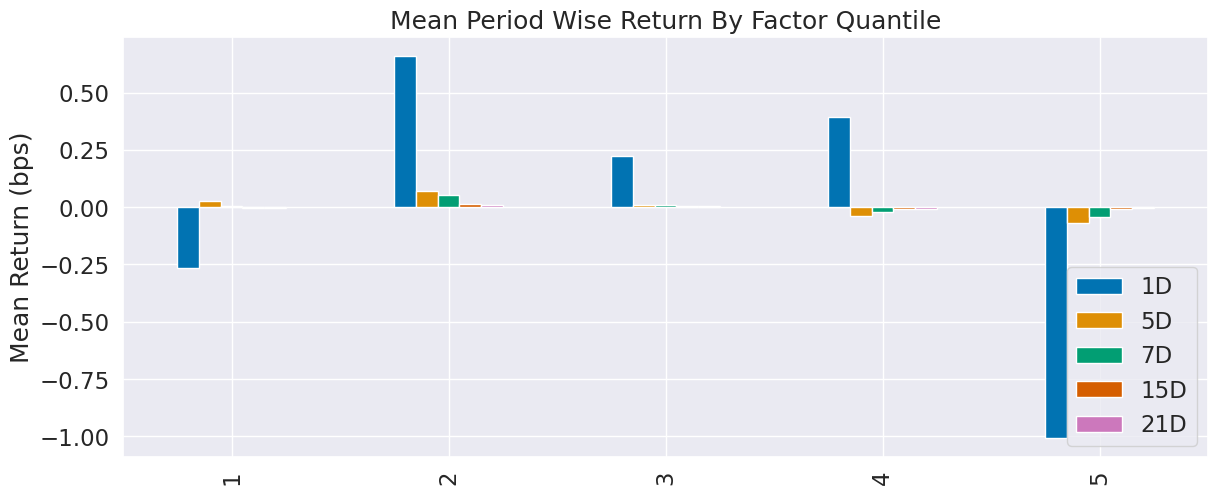

In [17]:
signal_evaluator.evaluate_signal(model=ridge17,feature_data=feature_data)

## Ridge Model-16 (alpha=5000)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.059197,0.007328,-0.004657,0.004491,113400,20.053582
2,-0.038857,0.009187,-0.001226,0.003200,113397,20.053052
3,-0.033953,0.010420,0.000297,0.002938,111891,19.786732
4,-0.029250,0.011853,0.001678,0.002718,113397,20.053052
5,-0.023511,0.026520,0.003913,0.002723,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.008,-0.002,-0.001,-0.000,-0.000
beta,0.006,0.010,0.014,0.018,0.014
Mean Period Wise Return Top Quantile (bps),-1.011,-0.053,-0.028,-0.004,-0.002
Mean Period Wise Return Bottom Quantile (bps),-0.197,0.030,0.014,0.000,-0.003
Mean Period Wise Spread (bps),-0.815,-0.083,-0.042,-0.004,0.001


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.003,-0.004,-0.003,-0.002,-0.001
IC Std.,0.052,0.051,0.050,0.050,0.051
Risk-Adjusted IC,-0.055,-0.071,-0.063,-0.031,-0.021
t-stat(IC),-2.126,-2.767,-2.431,-1.217,-0.835
p-value(IC),0.034,0.006,0.015,0.224,0.404
IC Skew,-0.113,0.017,0.082,0.092,0.062
IC Kurtosis,0.044,0.044,0.046,0.016,-0.110


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.678,0.715,0.766,0.789,0.766
Quantile 2 Mean Turnover,0.769,0.777,0.791,0.792,0.791
Quantile 3 Mean Turnover,0.782,0.789,0.790,0.793,0.794
Quantile 4 Mean Turnover,0.771,0.779,0.786,0.793,0.789
Quantile 5 Mean Turnover,0.684,0.728,0.782,0.785,0.756


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.222,0.144,0.031,0.008,0.071


<Figure size 640x480 with 0 Axes>

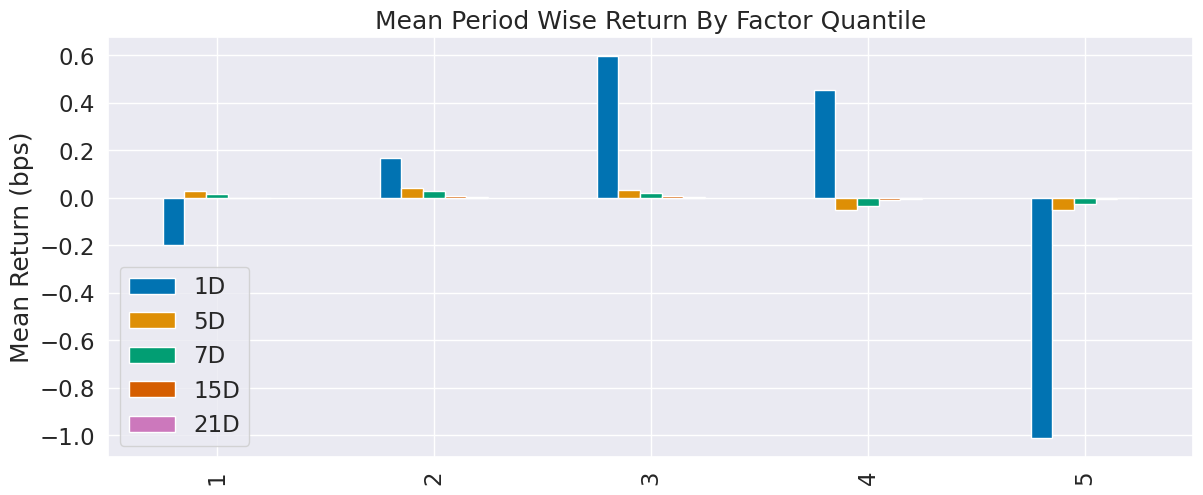

In [18]:
signal_evaluator.evaluate_signal(model=ridge16,feature_data=feature_data)

## Ridge Model-15 (alpha=1000)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.068169,0.008606,-0.005674,0.005293,113400,20.053582
2,-0.046248,0.010982,-0.001589,0.003825,113397,20.053052
3,-0.040368,0.012778,0.000291,0.003540,111891,19.786732
4,-0.034316,0.014593,0.002029,0.003313,113397,20.053052
5,-0.027871,0.034672,0.004947,0.003444,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.007,-0.001,-0.001,-0.000,-0.000
beta,0.006,0.009,0.013,0.017,0.014
Mean Period Wise Return Top Quantile (bps),-0.837,-0.042,-0.013,-0.003,0.001
Mean Period Wise Return Bottom Quantile (bps),-0.036,0.024,0.004,-0.001,-0.002
Mean Period Wise Spread (bps),-0.802,-0.067,-0.017,-0.002,0.003


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.003,-0.003,-0.003,-0.001,-0.001
IC Std.,0.052,0.051,0.051,0.050,0.051
Risk-Adjusted IC,-0.052,-0.058,-0.050,-0.026,-0.015
t-stat(IC),-2.036,-2.254,-1.945,-1.029,-0.587
p-value(IC),0.042,0.024,0.052,0.304,0.557
IC Skew,-0.095,0.082,0.117,0.100,0.091
IC Kurtosis,0.004,0.024,0.080,0.084,-0.087


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.737,0.733,0.769,0.795,0.775
Quantile 2 Mean Turnover,0.781,0.782,0.789,0.794,0.792
Quantile 3 Mean Turnover,0.785,0.789,0.792,0.792,0.795
Quantile 4 Mean Turnover,0.782,0.781,0.787,0.795,0.790
Quantile 5 Mean Turnover,0.738,0.739,0.778,0.789,0.767


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.094,0.11,0.032,-0.008,0.046


<Figure size 640x480 with 0 Axes>

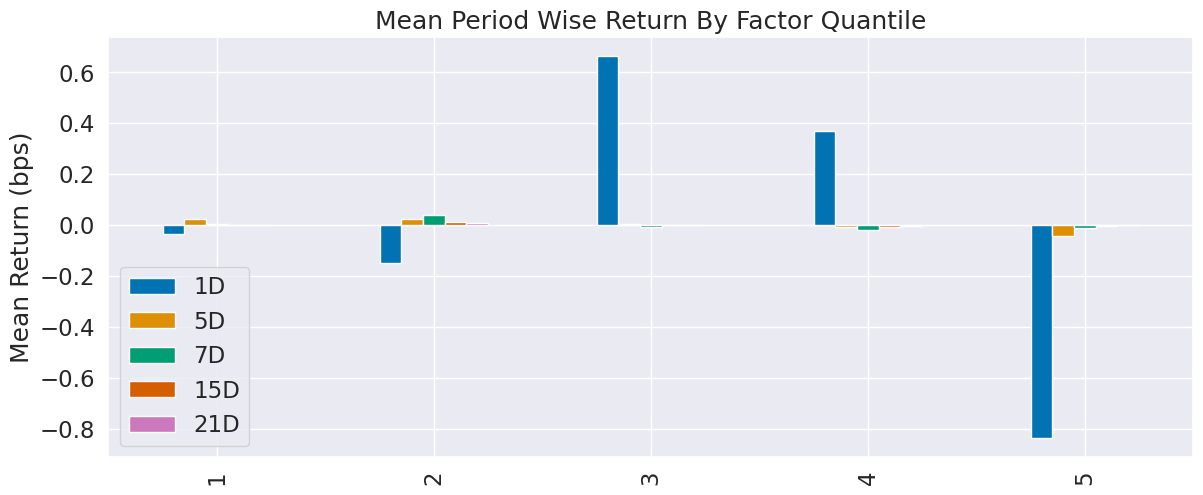

In [19]:
signal_evaluator.evaluate_signal(model=ridge15,feature_data=feature_data)

## Ridge Model-14 (alpha=500)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.068373,0.008715,-0.005919,0.005475,113400,20.053582
2,-0.046931,0.011463,-0.001675,0.003949,113397,20.053052
3,-0.040991,0.013423,0.000286,0.003658,111891,19.786732
4,-0.034826,0.015541,0.002109,0.003433,113397,20.053052
5,-0.028412,0.038193,0.005203,0.003626,113400,20.053582


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.007,-0.001,-0.001,-0.000,-0.000
beta,0.006,0.009,0.013,0.017,0.014
Mean Period Wise Return Top Quantile (bps),-0.901,-0.054,-0.023,-0.003,0.000
Mean Period Wise Return Bottom Quantile (bps),0.010,0.039,0.009,-0.000,-0.001
Mean Period Wise Spread (bps),-0.912,-0.094,-0.031,-0.002,0.001


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.003,-0.003,-0.002,-0.001,-0.001
IC Std.,0.052,0.051,0.051,0.050,0.051
Risk-Adjusted IC,-0.053,-0.054,-0.048,-0.025,-0.013
t-stat(IC),-2.050,-2.117,-1.849,-0.980,-0.513
p-value(IC),0.041,0.034,0.065,0.327,0.608
IC Skew,-0.086,0.091,0.121,0.092,0.089
IC Kurtosis,-0.022,0.016,0.091,0.092,-0.063


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.740,0.734,0.767,0.796,0.777
Quantile 2 Mean Turnover,0.781,0.784,0.789,0.795,0.792
Quantile 3 Mean Turnover,0.784,0.788,0.791,0.792,0.793
Quantile 4 Mean Turnover,0.783,0.780,0.786,0.796,0.790
Quantile 5 Mean Turnover,0.742,0.740,0.775,0.792,0.768


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.083,0.107,0.038,-0.014,0.043


<Figure size 640x480 with 0 Axes>

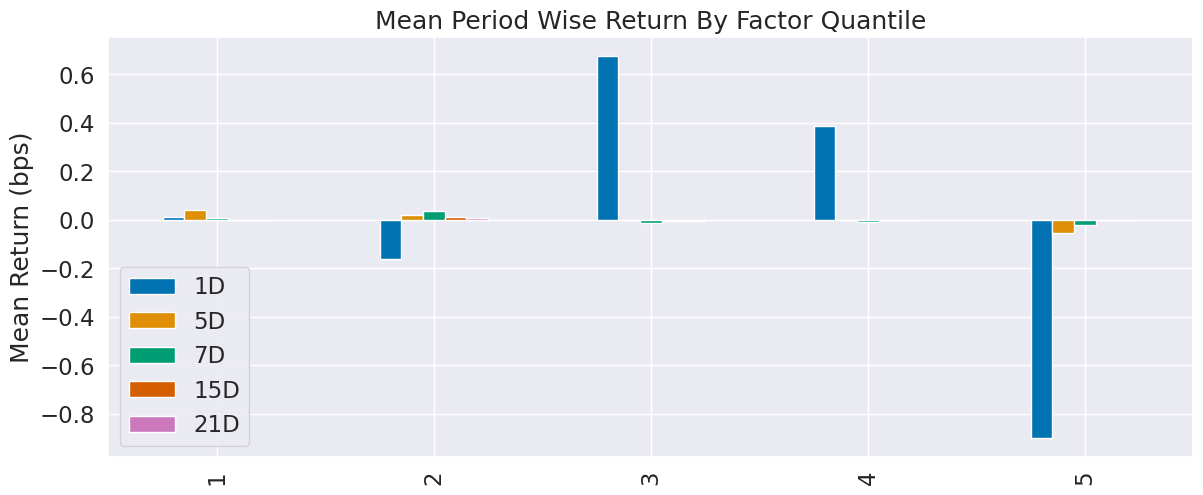

In [20]:
signal_evaluator.evaluate_signal(model=ridge14,feature_data=feature_data)